In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_FOLDER = "data"
VIS_FOLDER = "vis"
SETS = ['SetA', 'SetB', 'SetC']

In [3]:
def load_and_clean(set_name):
    print(f"Feldolgozás: {set_name}...")
    e_path = os.path.join(DATA_FOLDER, f"SCLDDOS2024_{set_name}_events.csv")
    c_path = os.path.join(DATA_FOLDER, f"SCLDDoS2024_{set_name}_components.csv")
    
    if not os.path.exists(e_path) or not os.path.exists(c_path):
        return None
    
   
    e_df = pd.read_csv(e_path, usecols=['Attack ID', 'Start time', 'End time', 'Type', 'Attack code'])
    c_df = pd.read_csv(c_path, usecols=['Attack ID', 'Packet speed', 'Data speed', 'Avg packet len', 'Source IP count'])
    
    df = e_df.merge(c_df, on='Attack ID', how='left')
    df['Set'] = set_name
    
    
    df['Start time'] = pd.to_datetime(df['Start time'], errors='coerce')
    df['End time'] = pd.to_datetime(df['End time'], errors='coerce')
    df['Duration_sec'] = (df['End time'] - df['Start time']).dt.total_seconds()
    

    df['Type'] = df['Type'].astype('category')
    df['Attack code'] = df['Attack code'].astype('category')
    
    return df

In [4]:
def prep_data(df):
    df_prep = df.copy()
    df_prep['Day_of_week'] = df_prep['Start time'].dt.dayofweek
    df_prep['Time_of_day'] = df_prep['Start time'].dt.hour // 6

    critical_cols = ['Packet speed', 'Data speed', 'Avg packet len', 'Source IP count', 'Duration_sec']
    df_prep = df_prep.dropna(subset=critical_cols + ['Type', 'Attack ID'])
    df_prep = df_prep[(df_prep['Duration_sec'] > 0) & (df_prep['Source IP count'] > 0)]

    df_prep['Packets_per_IP'] = df_prep['Packet speed'] / df_prep['Source IP count']

    features_to_keep = [
        'Attack ID', 'Packet speed', 'Data speed', 'Avg packet len', 
        'Source IP count', 'Packets_per_IP', 'Duration_sec', 
        'Day_of_week', 'Time_of_day', 'Type'
    ]
    df_final = df_prep[features_to_keep].copy()

    from sklearn.preprocessing import LabelEncoder
    le_type = LabelEncoder()
    df_final['Label'] = le_type.fit_transform(df_final['Type'].astype(str))

    X = df_final.drop(columns=['Type', 'Label'])
    y = df_final['Label']

    return X, y, le_type

In [5]:
# Load and prepare data for each set
datasets = {}
for s in SETS:
    data = load_and_clean(s)
    if data is not None:
        X, y, label_encoder = prep_data(data)
        datasets[s] = {'X': X.drop(columns=['Attack ID']), 'y': y, 'encoder': label_encoder}
        print(f"{s} - Samples: {len(X)}, Classes: {len(np.unique(y))}")

# Combine SetA and SetB for training
X_train = pd.concat([datasets['SetA']['X'], datasets['SetB']['X']], ignore_index=True)
y_train = pd.concat([datasets['SetA']['y'], datasets['SetB']['y']], ignore_index=True).values

# Split SetC into validation and test (50-50)
X_c = datasets['SetC']['X'].reset_index(drop=True)
y_c = datasets['SetC']['y'].values

X_val, X_test, y_val, y_test = train_test_split(X_c, y_c, test_size=0.5, random_state=42, stratify=y_c)

print(f"\nTraining set (SetA + SetB): {len(X_train)} samples")
print(f"Validation set (SetC - 50%): {len(X_val)} samples")
print(f"Test set (SetC - 50%): {len(X_test)} samples")
print(f"\nOriginal training class distribution:\n{np.bincount(y_train)}")

Feldolgozás: SetA...
SetA - Samples: 561823, Classes: 3
Feldolgozás: SetB...
SetB - Samples: 1231341, Classes: 3
Feldolgozás: SetC...
SetC - Samples: 1246508, Classes: 3

Training set (SetA + SetB): 1793164 samples
Validation set (SetC - 50%): 623254 samples
Test set (SetC - 50%): 623254 samples

Original training class distribution:
[ 277269 1451686   64209]


In [6]:
# Apply SMOTE upsampling ONLY on training data (SetA) to avoid data leakage
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Upsampled training class distribution:")
print(np.bincount(y_train_resampled))
print(f"\nTraining set after SMOTE: {len(X_train_resampled)} samples")

Upsampled training class distribution:
[1451686 1451686 1451686]

Training set after SMOTE: 4355058 samples


In [17]:
# Tune only Random Forest using the validation split from SetC
print("Starting Random Forest hyperparameter tuning with progress tracking...")

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 12, 16, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

n_iter = 10
cv_folds = 3

def sample_random_params(param_dist, n_iter=30, random_state=42):
    rng = np.random.default_rng(random_state)
    samples = []
    for _ in range(n_iter):
        candidate = {}
        for key, values in param_dist.items():
            candidate[key] = rng.choice(values) if isinstance(values, (list, tuple, np.ndarray)) else values
        samples.append(candidate)
    return samples

param_candidates = sample_random_params(param_dist, n_iter=n_iter, random_state=42)
total_fits = n_iter * cv_folds
print(f"Randomized search will evaluate {n_iter} candidates with {cv_folds} folds each.")
print(f"Total fits to run: {total_fits}\n")

from sklearn.model_selection import cross_val_score, StratifiedKFold

kf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
best_score = -np.inf
best_params = None
fit_count = 0

for idx, params in enumerate(param_candidates, start=1):
    print(f"Candidate {idx}/{n_iter}: {params}")
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
    cv_scores = cross_val_score(
        model,
        X_train_resampled,
        y_train_resampled,
        scoring='f1_weighted',
        cv=kf,
        n_jobs=-1
    )
    fit_count += len(cv_scores)
    mean_score = np.mean(cv_scores)
    print(f"  Mean CV weighted F1: {mean_score:.4f} | fits done: {fit_count}/{total_fits}\n")

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

best_rf = RandomForestClassifier(random_state=42, n_jobs=-1, **best_params)
best_rf.fit(X_train_resampled, y_train_resampled)
print("\nBest Random Forest parameters:")
print(best_params)
print(f"Best CV weighted F1: {best_score:.4f}")

# Evaluate the best RF on validation and test splits
y_pred_val = best_rf.predict(X_val)
y_pred_test = best_rf.predict(X_test)
models = {'Random Forest': {'model': best_rf, 'pred_val': y_pred_val, 'pred_test': y_pred_test}}
print("\nRandom Forest tuning and evaluation setup complete.")

Starting Random Forest hyperparameter tuning with progress tracking...
Randomized search will evaluate 10 candidates with 3 folds each.
Total fits to run: 30

Candidate 1/10: {'n_estimators': np.int64(100), 'max_depth': np.int64(20), 'min_samples_split': np.int64(5), 'min_samples_leaf': np.int64(2), 'max_features': np.str_('sqrt')}
  Mean CV weighted F1: 0.9590 | fits done: 3/30

Candidate 2/10: {'n_estimators': np.int64(300), 'max_depth': np.int64(8), 'min_samples_split': np.int64(10), 'min_samples_leaf': np.int64(1), 'max_features': np.str_('sqrt')}
  Mean CV weighted F1: 0.8486 | fits done: 6/30

Candidate 3/10: {'n_estimators': np.int64(200), 'max_depth': np.int64(20), 'min_samples_split': np.int64(10), 'min_samples_leaf': np.int64(4), 'max_features': np.str_('log2')}
  Mean CV weighted F1: 0.9694 | fits done: 9/30

Candidate 4/10: {'n_estimators': np.int64(300), 'max_depth': np.int64(16), 'min_samples_split': np.int64(2), 'min_samples_leaf': np.int64(4), 'max_features': np.str_('s

In [10]:


#create a random forest : Candidate 3/10: {'n_estimators': np.int64(200), 'max_depth': np.int64(20), 'min_samples_split': np.int64(10), 'min_samples_leaf': np.int64(4), 'max_features': np.str_('log2')}
best_rf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=200, max_depth=20, min_samples_split=10, min_samples_leaf=4, max_features='log2')
best_rf.fit(X_train_resampled, y_train_resampled)



y_pred_val = best_rf.predict(X_val)
y_pred_test = best_rf.predict(X_test)
models = {'Random Forest': {'model': best_rf, 'pred_val': y_pred_val, 'pred_test': y_pred_test}}
print("\nRandom Forest tuning and evaluation setup complete.")


Random Forest tuning and evaluation setup complete.


In [18]:
# Evaluate the tuned Random Forest on the validation split from SetC
print("="*80)
print("VALIDATION SET (SetC split) RESULTS")
print("="*80)

validation_results = {}
model_name = 'Random Forest'
y_pred = models[model_name]['pred_val']
acc = accuracy_score(y_val, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_, zero_division=0))
validation_results[model_name] = {
    'accuracy': acc,
    'precision': precision_score(y_val, y_pred, average='weighted', zero_division=0),
    'recall': recall_score(y_val, y_pred, average='weighted', zero_division=0),
    'f1': f1_score(y_val, y_pred, average='weighted', zero_division=0)
}

VALIDATION SET (SetC split) RESULTS
Accuracy: 0.7099

Classification Report:
                    precision    recall  f1-score   support

       DDoS attack       0.48      0.53      0.50    152582
    Normal traffic       0.84      0.78      0.81    459233
Suspicious traffic       0.10      0.22      0.14     11439

          accuracy                           0.71    623254
         macro avg       0.47      0.51      0.48    623254
      weighted avg       0.73      0.71      0.72    623254



In [12]:
# Evaluate the tuned Random Forest on the test split from SetC
print("\n" + "="*80)
print("TEST SET (SetC split) RESULTS")
print("="*80)

test_results = {}
model_name = 'Random Forest'
y_pred = models[model_name]['pred_test']
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))
test_results[model_name] = {
    'accuracy': acc,
    'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred, average='weighted', zero_division=0)
}


TEST SET (SetC split) RESULTS
Accuracy: 0.7123

Classification Report:
                    precision    recall  f1-score   support

       DDoS attack       0.48      0.53      0.50    152582
    Normal traffic       0.84      0.78      0.81    459233
Suspicious traffic       0.11      0.22      0.15     11439

          accuracy                           0.71    623254
         macro avg       0.48      0.51      0.49    623254
      weighted avg       0.74      0.71      0.72    623254



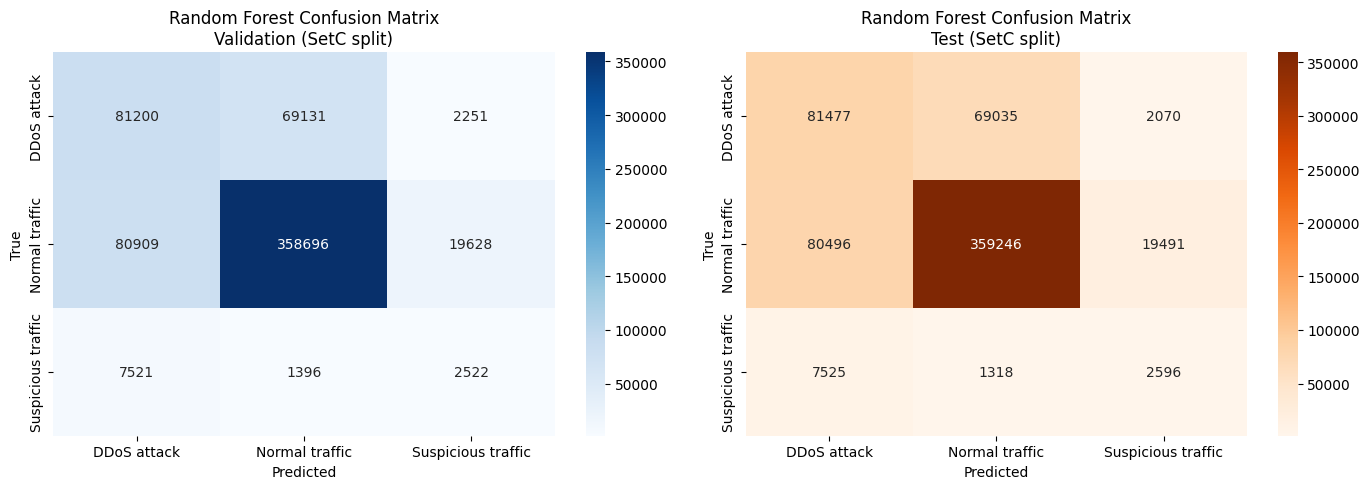

Confusion matrices saved to vis/rf_confusion_matrices.png


In [19]:
# Visualize confusion matrices for validation and test splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation matrix
cm_val = confusion_matrix(y_val, models['Random Forest']['pred_val'])
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[0].set_title('Random Forest Confusion Matrix\nValidation (SetC split)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Test matrix
cm_test = confusion_matrix(y_test, models['Random Forest']['pred_test'])
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
axes[1].set_title('Random Forest Confusion Matrix\nTest (SetC split)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(VIS_FOLDER, 'rf_confusion_matrices.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Confusion matrices saved to vis/rf_confusion_matrices.png")

In [20]:
# Az alábbi cella inaktív, mert a Random Foresthez csak az előző ábrák szükségesek.
# A korábbi többszörös modell összehasonlítást lecseréltük egyetlen, finomhangolt RF pipeline-ra.
print("A validációs és teszt konfúziós mátrixok a korábbi cellában találhatók.")

A validációs és teszt konfúziós mátrixok a korábbi cellában találhatók.


VALIDATION SET (SetC split) METRICS
               accuracy  precision  recall      f1
Random Forest    0.7099     0.7348  0.7099  0.7209

TEST SET (SetC split) METRICS
               accuracy  precision  recall      f1
Random Forest    0.7123      0.735  0.7123  0.7224


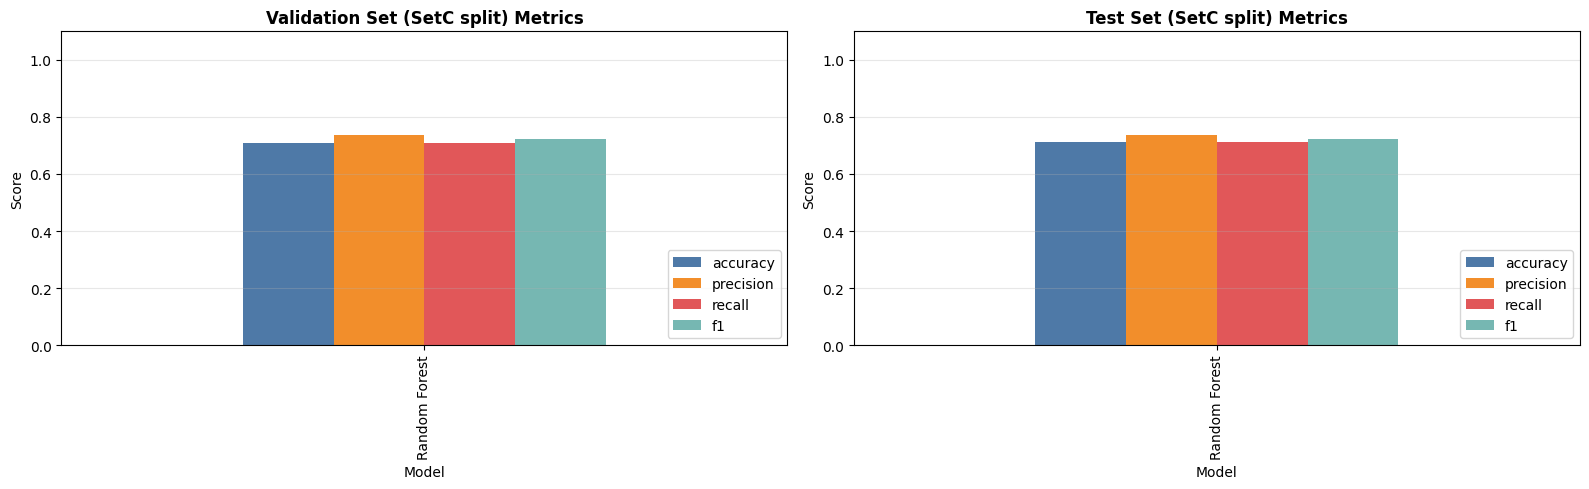


Performance comparison chart saved to vis/rf_performance_metrics.png


In [21]:
# Compare performance metrics for the tuned Random Forest
import pandas as pd

# Create comparison dataframes
val_results_df = pd.DataFrame(validation_results).T
test_results_df = pd.DataFrame(test_results).T

print("="*80)
print("VALIDATION SET (SetC split) METRICS")
print("="*80)
print(val_results_df.round(4))

print("\n" + "="*80)
print("TEST SET (SetC split) METRICS")
print("="*80)
print(test_results_df.round(4))

# Visualize performance metrics for Random Forest
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

val_results_df.plot(kind='bar', ax=axes[0], color=['#4E79A7', '#F28E2B', '#E15759', '#76B7B2'])
axes[0].set_title('Validation Set (SetC split) Metrics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=10)
axes[0].set_xlabel('Model', fontsize=10)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1.1])

test_results_df.plot(kind='bar', ax=axes[1], color=['#4E79A7', '#F28E2B', '#E15759', '#76B7B2'])
axes[1].set_title('Test Set (SetC split) Metrics', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Score', fontsize=10)
axes[1].set_xlabel('Model', fontsize=10)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig(os.path.join(VIS_FOLDER, 'rf_performance_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nPerformance comparison chart saved to vis/rf_performance_metrics.png")

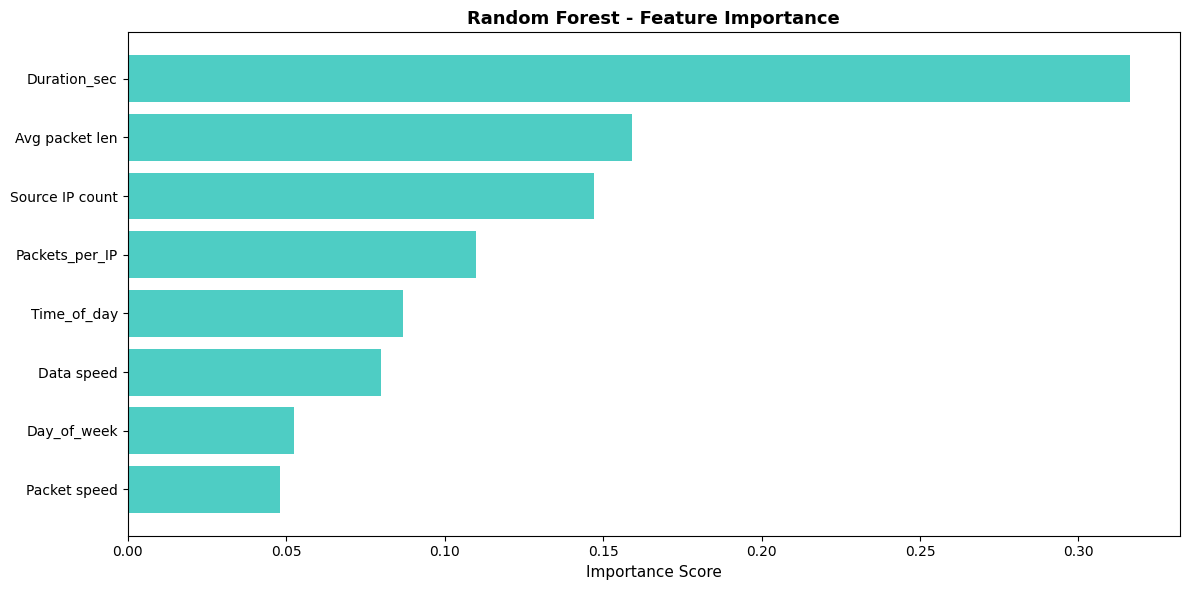


Feature importance chart saved to vis/feature_importance_random_forest.png

Top 10 Most Important Features:
        feature  importance
   Duration_sec    0.316214
 Avg packet len    0.159268
Source IP count    0.146996
 Packets_per_IP    0.109772
    Time_of_day    0.086971
     Data speed    0.080080
    Day_of_week    0.052530
   Packet speed    0.048168


In [22]:
# Feature Importance Analysis (Random Forest)
rf_model = models['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(feature_importance['feature'], feature_importance['importance'], color='#4ECDC4')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Random Forest - Feature Importance', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(VIS_FOLDER, 'feature_importance_random_forest.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature importance chart saved to vis/feature_importance_random_forest.png")
print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [16]:
# Create a concise RF summary report
print("="*100)
print("RANDOM FOREST MODEL SUMMARY")
print("="*100)

summary_data = {
    'Model': [],
    'Set': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

model_name = 'Random Forest'
summary_data['Model'].append(model_name)
summary_data['Set'].append('Validation (SetC split)')
summary_data['Accuracy'].append(f"{validation_results[model_name]['accuracy']:.4f}")
summary_data['Precision'].append(f"{validation_results[model_name]['precision']:.4f}")
summary_data['Recall'].append(f"{validation_results[model_name]['recall']:.4f}")
summary_data['F1-Score'].append(f"{validation_results[model_name]['f1']:.4f}")

summary_data['Model'].append(model_name)
summary_data['Set'].append('Test (SetC split)')
summary_data['Accuracy'].append(f"{test_results[model_name]['accuracy']:.4f}")
summary_data['Precision'].append(f"{test_results[model_name]['precision']:.4f}")
summary_data['Recall'].append(f"{test_results[model_name]['recall']:.4f}")
summary_data['F1-Score'].append(f"{test_results[model_name]['f1']:.4f}")

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

summary_df.to_csv(os.path.join(VIS_FOLDER, 'rf_model_summary.csv'), index=False)
print("\n✓ Summary saved to vis/rf_model_summary.csv")

print("\n" + "="*100)
print("KEY FINDINGS")
print("="*100)
print(f"✓ Tuned model: Random Forest")
print(f"✓ Training data: SetA + SetB with SMOTE upsampling ({len(X_train_resampled)} samples)")
print(f"✓ Validation data: SetC split ({len(X_val)} samples)")
print(f"✓ Test data: SetC split ({len(X_test)} samples)")
print(f"✓ Final test accuracy: {test_results[model_name]['accuracy']:.4f}")
print(f"✓ Final test weighted F1: {test_results[model_name]['f1']:.4f}")

RANDOM FOREST MODEL SUMMARY

        Model                     Set Accuracy Precision Recall F1-Score
Random Forest Validation (SetC split)   0.7109    0.7343 0.7109   0.7213
Random Forest       Test (SetC split)   0.7123    0.7350 0.7123   0.7224

✓ Summary saved to vis/rf_model_summary.csv

KEY FINDINGS
✓ Tuned model: Random Forest
✓ Training data: SetA + SetB with SMOTE upsampling (4355058 samples)
✓ Validation data: SetC split (623254 samples)
✓ Test data: SetC split (623254 samples)
✓ Final test accuracy: 0.7123
✓ Final test weighted F1: 0.7224
